Create Model And Training the Raw Data

In [1]:
# importing libraries for model training
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler,LabelEncoder,OrdinalEncoder

In [2]:
# importing libraries for model training
from sklearn.linear_model import LinearRegression,Lasso,Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import *

In [3]:
# Load the dataset
df = pd.read_csv(
    r'C:\Users\user\OneDrive\Desktop\supplychain\data\DataCoSupplyChainDataset.csv',
    encoding='latin1'
)

In [4]:
# Check shape
df.shape

(180519, 53)

In [5]:
# Unsderstand the dataset
df.head(5)

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [6]:
# Get information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Email                 180519 non-null  object 
 12  Customer Fname                

In [7]:
# Get descriptive statistics for the dataset
df.describe(include='all')

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
count,180519,180519.000000,180519.000000,180519.000000,180519.000000,180519,180519.000000,180519.000000,180519,180519,...,24840.000000,180519.000000,180519.000000,0.0,180519,180519,180519.000000,180519.0,180519,180519
unique,4,NaN,NaN,NaN,NaN,4,NaN,NaN,50,563,...,NaN,NaN,NaN,NaN,118,118,NaN,NaN,63701,4
top,DEBIT,NaN,NaN,NaN,NaN,Late delivery,NaN,NaN,Cleats,Caguas,...,NaN,NaN,NaN,NaN,http://images.acmesports.sports/Perfect+Fitnes...,Perfect Fitness Perfect Rip Deck,NaN,NaN,1/5/2016 5:58,Standard Class
freq,69295,NaN,NaN,NaN,NaN,98977,NaN,NaN,24551,66770,...,NaN,NaN,NaN,NaN,24515,24515,NaN,NaN,10,107752
mean,NaN,3.497654,2.931847,21.974989,183.107609,NaN,0.548291,31.851451,NaN,NaN,...,55426.132327,692.509764,31.851451,NaN,NaN,NaN,141.232550,0.0,NaN,NaN
std,NaN,1.623722,1.374449,104.433526,120.043670,NaN,0.497664,15.640064,NaN,NaN,...,31919.279101,336.446807,15.640064,NaN,NaN,NaN,139.732492,0.0,NaN,NaN
min,NaN,0.000000,0.000000,-4274.979980,7.490000,NaN,0.000000,2.000000,NaN,NaN,...,1040.000000,19.000000,2.000000,NaN,NaN,NaN,9.990000,0.0,NaN,NaN
25%,NaN,2.000000,2.000000,7.000000,104.379997,NaN,0.000000,18.000000,NaN,NaN,...,23464.000000,403.000000,18.000000,NaN,NaN,NaN,50.000000,0.0,NaN,NaN
50%,NaN,3.000000,4.000000,31.520000,163.990005,NaN,1.000000,29.000000,NaN,NaN,...,59405.000000,627.000000,29.000000,NaN,NaN,NaN,59.990002,0.0,NaN,NaN
75%,NaN,5.000000,4.000000,64.800003,247.399994,NaN,1.000000,45.000000,NaN,NaN,...,90008.000000,1004.000000,45.000000,NaN,NaN,NaN,199.990005,0.0,NaN,NaN


In [8]:
# countvalues in each column
for col in df.columns:
    print(f"Column: {col}")
    print(f"value counts:\n{df[col].value_counts()}\n")

Column: Type
value counts:
Type
DEBIT       69295
TRANSFER    49883
PAYMENT     41725
CASH        19616
Name: count, dtype: int64

Column: Days for shipping (real)
value counts:
Days for shipping (real)
2    56618
3    28765
6    28723
4    28513
5    28163
0     5080
1     4657
Name: count, dtype: int64

Column: Days for shipment (scheduled)
value counts:
Days for shipment (scheduled)
4    107752
2     35216
1     27814
0      9737
Name: count, dtype: int64

Column: Benefit per order
value counts:
Benefit per order
 0.000000      1177
 143.990005     199
 72.000000      194
 46.799999      188
 24.000000      181
               ... 
-48.830002        1
 48.220001        1
-145.729996       1
-330.109985       1
-337.100006       1
Name: count, Length: 21998, dtype: int64

Column: Sales per customer
value counts:
Sales per customer
122.839996    1264
109.190002    1247
124.790001    1243
129.990005    1243
116.989998    1243
              ... 
455.950012       1
470.250000       1
424.

In [9]:
# Count missing values in each column
df.isnull().sum()

Type                                  0
Days for shipping (real)              0
Days for shipment (scheduled)         0
Benefit per order                     0
Sales per customer                    0
Delivery Status                       0
Late_delivery_risk                    0
Category Id                           0
Category Name                         0
Customer City                         0
Customer Country                      0
Customer Email                        0
Customer Fname                        0
Customer Id                           0
Customer Lname                        8
Customer Password                     0
Customer Segment                      0
Customer State                        0
Customer Street                       0
Customer Zipcode                      3
Department Id                         0
Department Name                       0
Latitude                              0
Longitude                             0
Market                                0


In [10]:
# Drop unnecessary columns, such as 'Order Zipcode' and 'Product Description', which may not be relevant for analysis
df.drop(columns=['Order Zipcode','Product Description'],inplace=True)

In [11]:
# Drop rows with missing values
df.dropna(inplace=True)

In [12]:
# Check for null values after dropping 
df.isnull().sum()

Type                             0
Days for shipping (real)         0
Days for shipment (scheduled)    0
Benefit per order                0
Sales per customer               0
Delivery Status                  0
Late_delivery_risk               0
Category Id                      0
Category Name                    0
Customer City                    0
Customer Country                 0
Customer Email                   0
Customer Fname                   0
Customer Id                      0
Customer Lname                   0
Customer Password                0
Customer Segment                 0
Customer State                   0
Customer Street                  0
Customer Zipcode                 0
Department Id                    0
Department Name                  0
Latitude                         0
Longitude                        0
Market                           0
Order City                       0
Order Country                    0
Order Customer Id                0
order date (DateOrde

In [13]:
# Check for duplicate rows in the dataset
df.duplicated().sum()

np.int64(0)

In [14]:
# Identify text columns
text_columns = df.select_dtypes(
    include=["object", "string"]
).columns

print(text_columns)

Index(['Type', 'Delivery Status', 'Category Name', 'Customer City',
       'Customer Country', 'Customer Email', 'Customer Fname',
       'Customer Lname', 'Customer Password', 'Customer Segment',
       'Customer State', 'Customer Street', 'Department Name', 'Market',
       'Order City', 'Order Country', 'order date (DateOrders)',
       'Order Region', 'Order State', 'Order Status', 'Product Image',
       'Product Name', 'shipping date (DateOrders)', 'Shipping Mode'],
      dtype='object')


In [15]:
# Remove leading and trailing whitespace from text columns
for column in text_columns:
    df[column] = df[column].str.strip()

In [16]:
# Drop unnecessary columns
df.drop(columns=[
    "Customer Email",
    "Customer Password",
    "Customer Fname",
    "Customer Lname",
    "Customer Street",
    "Customer Zipcode",
    "Product Image"
], inplace=True)

In [17]:
# Convert date columns to datetime format
df["order date (DateOrders)"] = pd.to_datetime(
    df["order date (DateOrders)"],
    errors="coerce"
)

df["shipping date (DateOrders)"] = pd.to_datetime(
    df["shipping date (DateOrders)"],
    errors="coerce"
)

In [18]:
# Check the data types of the date columns
print(df["order date (DateOrders)"].dtype)
print(df["shipping date (DateOrders)"].dtype)

datetime64[ns]
datetime64[ns]


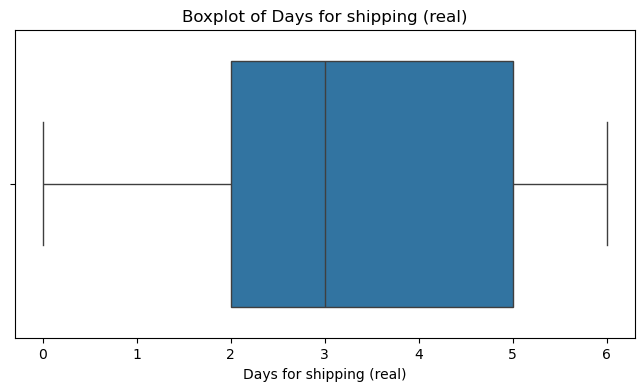

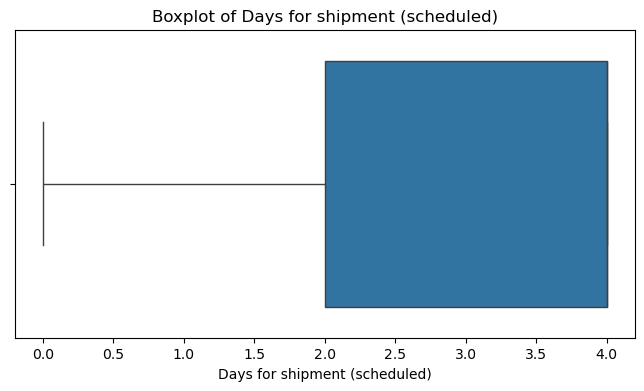

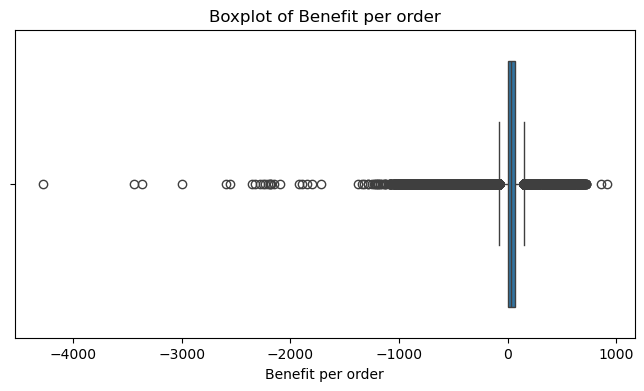

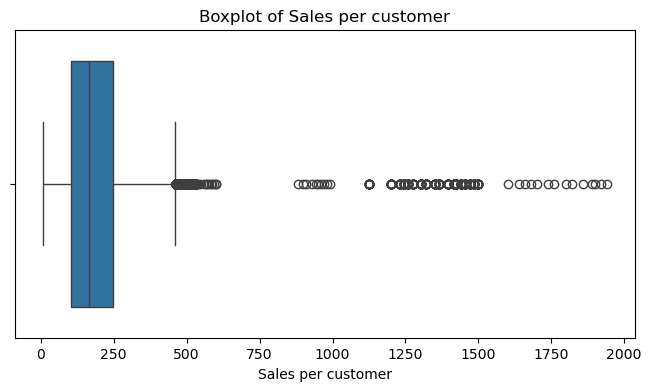

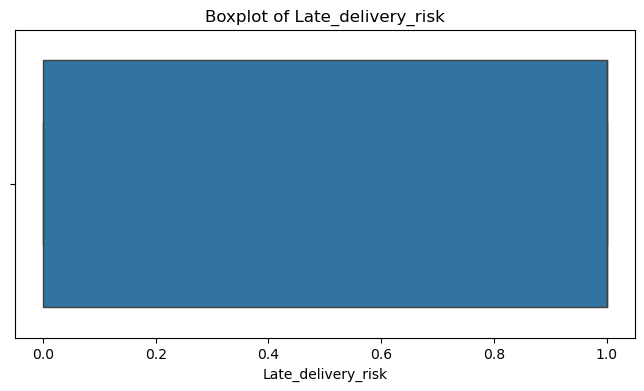

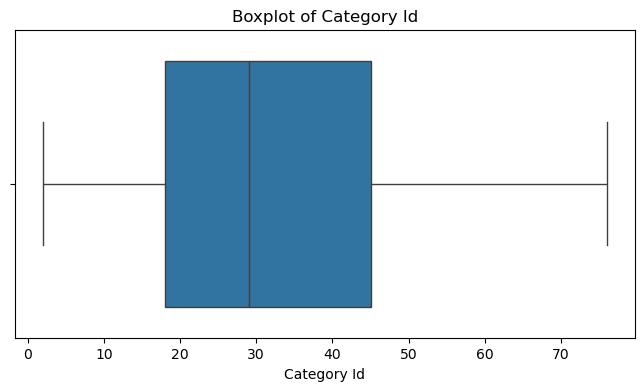

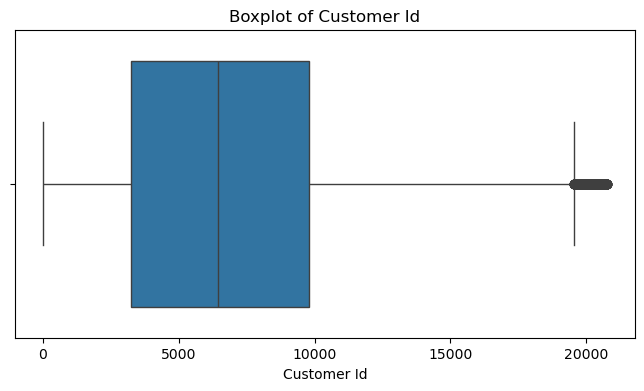

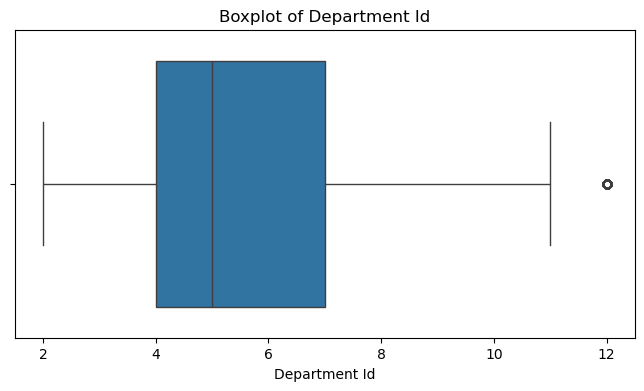

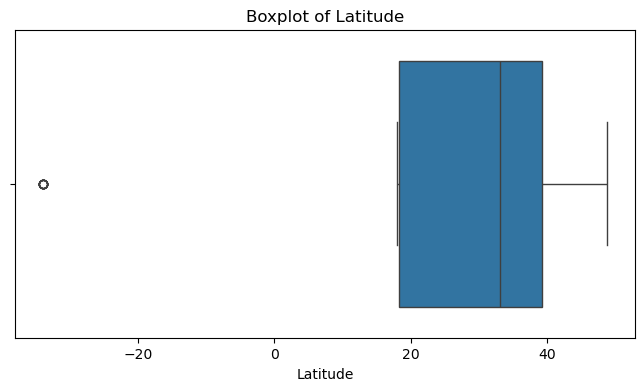

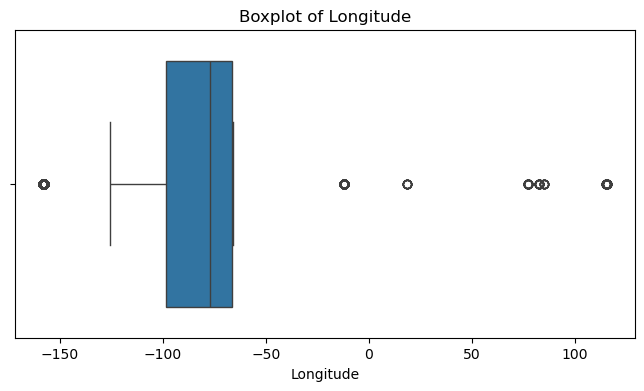

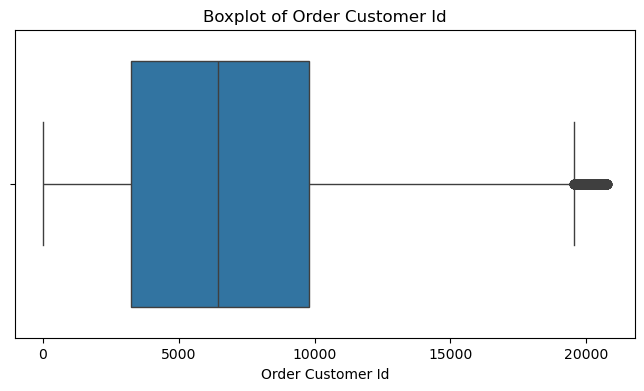

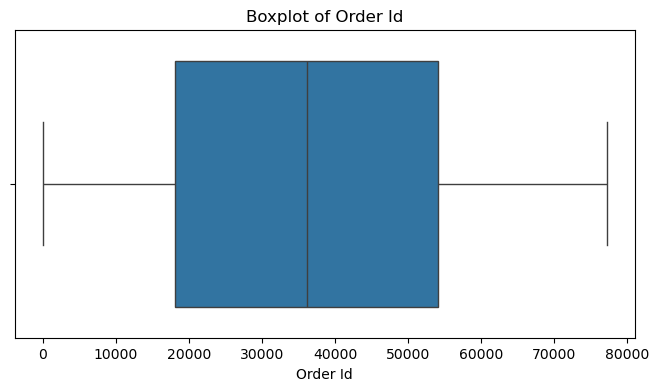

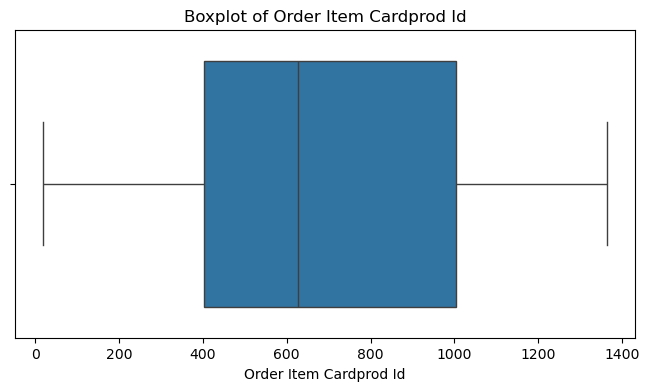

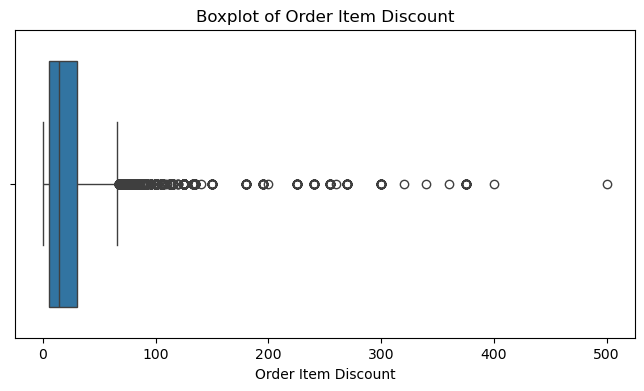

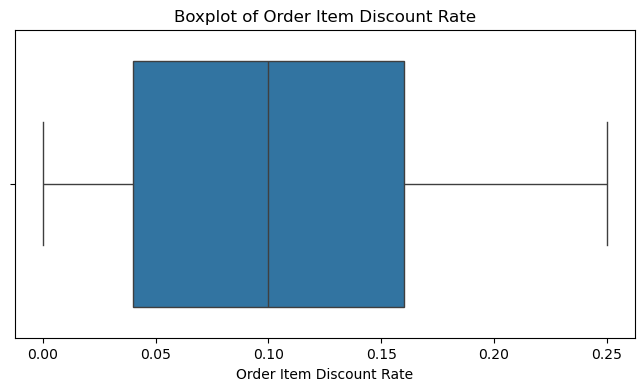

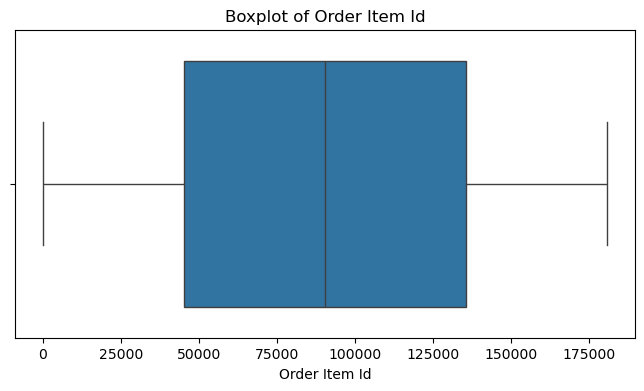

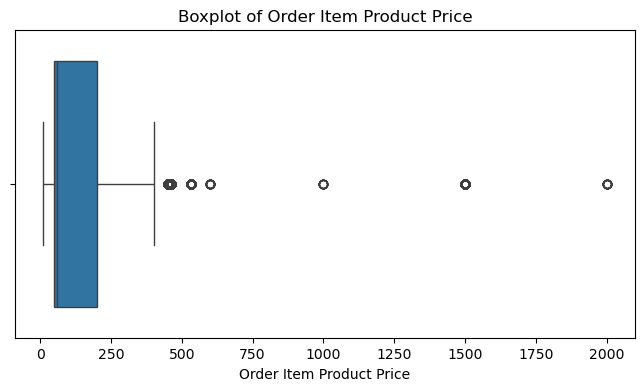

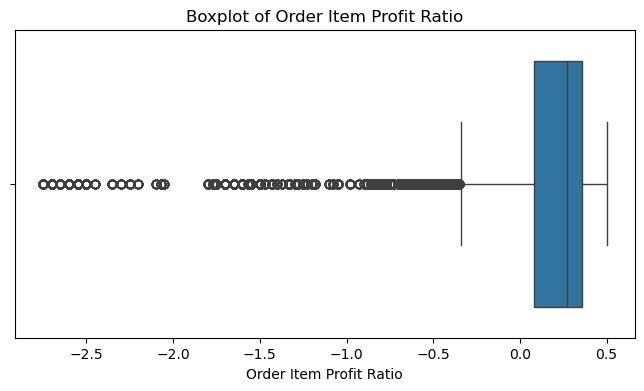

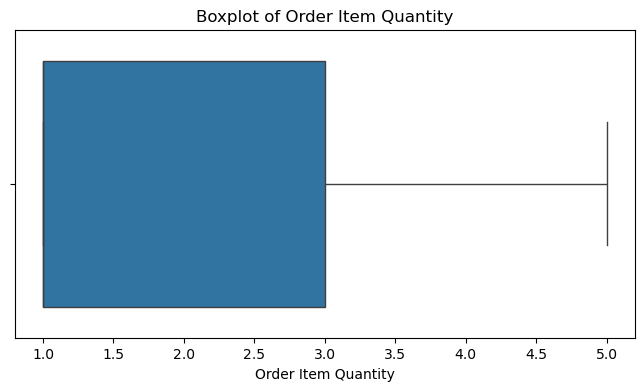

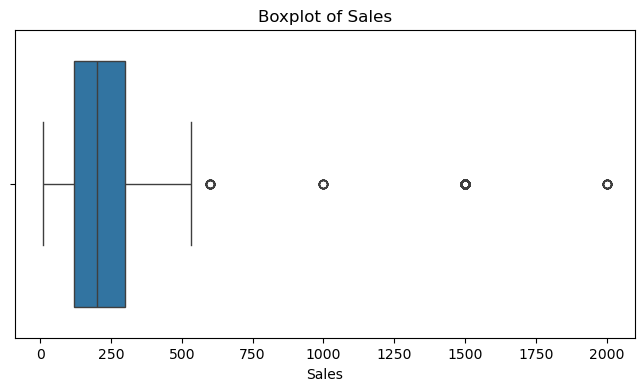

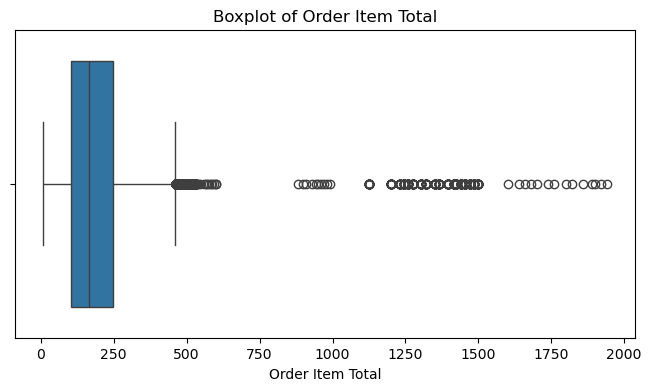

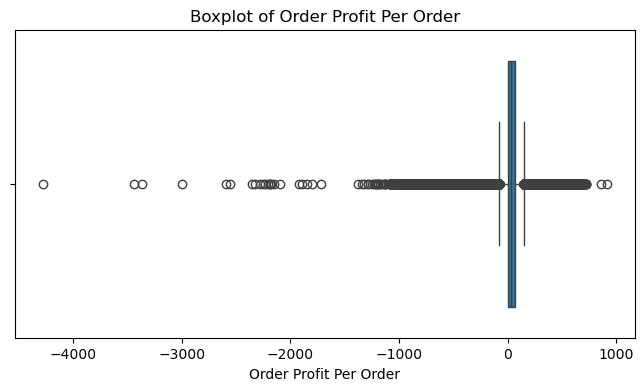

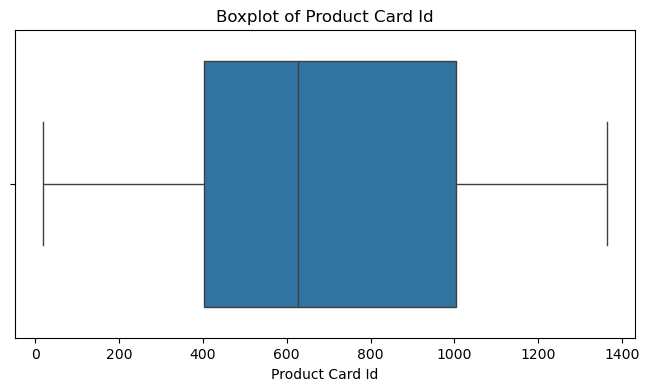

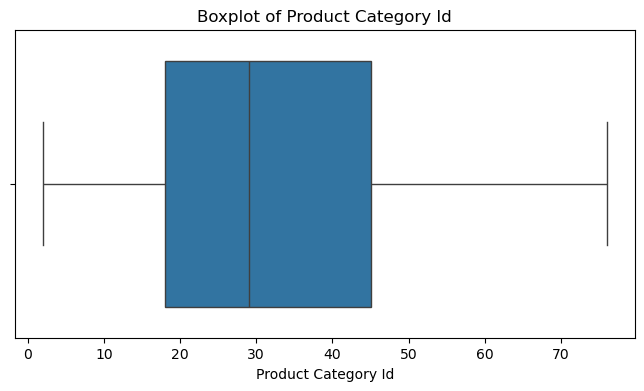

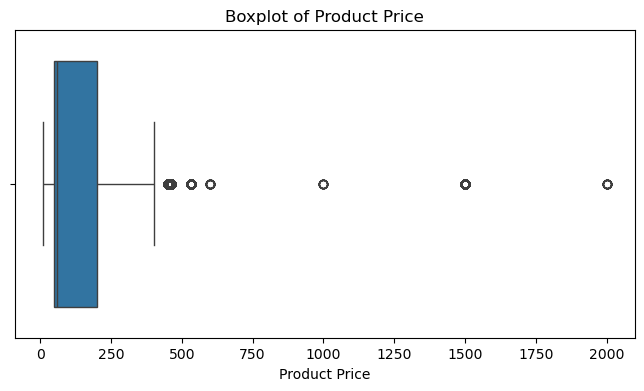

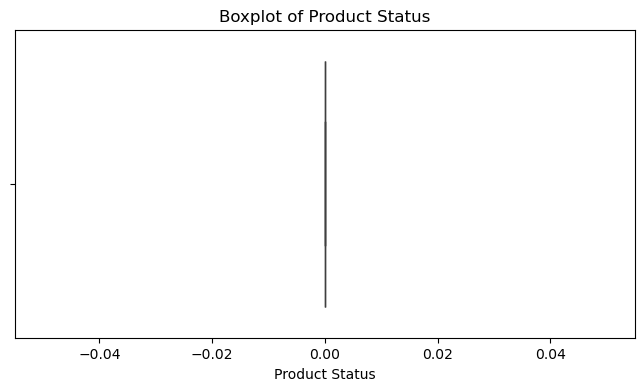

In [19]:
#  Check outliers in the dataset using boxplots for numerical columns
numerical_columns = df.select_dtypes(include=[np.number]).columns
for col in numerical_columns:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

# 🧹 Data Cleaning

The raw supply chain dataset was cleaned and prepared for Exploratory Data Analysis (EDA).

## Data Cleaning Steps

The following data cleaning steps were performed:

1. Loaded the raw CSV dataset using Pandas.
2. Inspected the dataset structure, rows, columns, and data types.
3. Checked for missing values.
4. Checked and removed duplicate records.
5. Checked numeric columns for invalid values.
6. Standardized column names and text values where required.
7. Removed unnecessary and sensitive customer information.
8. Converted date columns into proper datetime format.
9. Validated numeric columns and their data types.
10. Created useful features for further analysis.
11. Performed final data quality checks.

## Data Privacy

Sensitive customer information was removed before analysis, including:

- Customer Email
- Customer Password
- Customer First Name
- Customer Last Name
- Customer Street Address
- Customer Zipcode
- Product Image

## Final Dataset

After data cleaning:

- **Rows:** 180,508
- **Columns:** 44
- **Duplicate records:** Removed
- **Date columns:** Converted to datetime
- **Numeric columns:** Validated
- **Sensitive information:** Removed

The cleaned dataset is now ready for **Exploratory Data Analysis (EDA), Data Visualization, and Business Insights**.

# Machine Learning Model Training & Evaluatio

In [20]:
# Separate featues and target columns
x = df.drop(columns="Shipping Mode")
y = df["Shipping Mode"]

In [21]:
# Remove column Date and Time
date_cols = x.select_dtypes(include=['datetime64[ns]', 'datetime64']).columns

x = x.drop(columns=date_cols)

print("Removed:", list(date_cols))

Removed: ['order date (DateOrders)', 'shipping date (DateOrders)']


In [22]:
'''sc=StandardScaler()
for i in x.columns:
    if x[i].dtype!='str':
        x[i]=sc.fit_transform(x[[i]])'''

"sc=StandardScaler()\nfor i in x.columns:\n    if x[i].dtype!='str':\n        x[i]=sc.fit_transform(x[[i]])"

In [23]:
# Apply OrdinalEncoder
from sklearn.preprocessing import OrdinalEncoder
categorical_cols = x.select_dtypes(include=['object']).columns
encoder = OrdinalEncoder(
    handle_unknown='use_encoded_value',
    unknown_value=-1
)
x[categorical_cols] = encoder.fit_transform(x[categorical_cols])


In [24]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)
print(y[:10])
print(le.classes_)

[3 3 3 3 3 3 0 0 2 0]
['First Class' 'Same Day' 'Second Class' 'Standard Class']


In [25]:
# Unsderstand the x features
x.shape

(180508, 41)

In [26]:
# understand the y target
y.shape

(180508,)

In [27]:
# train test split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [28]:
# Model Evaluation Function

def evaluate_model(true, pred):
    mae = mean_absolute_error(true, pred)
    mse = mean_squared_error(true, pred)
    rmse = np.sqrt(mse)
    r2_square = r2_score(true, pred)

    return mae, mse, rmse, r2_square


# Models

models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(),
    'Lasso Regression': Lasso(),
    'KNN Regression': KNeighborsRegressor(),
    'Decision Tree Regression': DecisionTreeRegressor(),
    'Random Forest Regression': RandomForestRegressor(),
    'XGB Regression': XGBRegressor(),
  
    'AdaBoost Regression': AdaBoostRegressor()
}


# Lists for storing results

model_list = []
r2_list = []


# Train and Evaluate Models

for i in range(len(list(models))):

    model = list(models.values())[i]

    # Train model
    model.fit(x_train, y_train)

    # Make predictions
    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)

    # Evaluate Test Data
    mae, mse, rmse, r2_square = evaluate_model(
        y_test,
        y_test_pred
    )

    # Evaluate Training Data
    train_mae, train_mse, train_rmse, train_r2_square = evaluate_model(
        y_train,
        y_train_pred
    )

    # Store results
    r2_list.append(r2_square)
    model_list.append(list(models.keys())[i])

    # Print results
    print(list(models.keys())[i])

    print("Model performance for Training set")
    print("- MAE:", train_mae)
    print("- MSE:", train_mse)
    print("- RMSE:", train_rmse)
    print("- R2 Score:", train_r2_square)

    print("\nModel performance for Test set")
    print("- MAE:", mae)
    print("- MSE:", mse)
    print("- RMSE:", rmse)
    print("- R2 Score:", r2_square)

    print("=" * 50)

Linear Regression
Model performance for Training set
- MAE: 0.2860573037261969
- MSE: 0.15441134459529884
- RMSE: 0.39295208944004717
- R2 Score: 0.8724867648333089

Model performance for Test set
- MAE: 0.2893158538940174
- MSE: 0.15740630639000738
- RMSE: 0.39674463624604606
- R2 Score: 0.8705831055868573
Ridge Regression
Model performance for Training set
- MAE: 0.2860570281621444
- MSE: 0.15441271958926506
- RMSE: 0.39295383900563313
- R2 Score: 0.8724856293602035

Model performance for Test set
- MAE: 0.2893288734327087
- MSE: 0.15741388019907565
- RMSE: 0.3967541810732127
- R2 Score: 0.870576878524734
Lasso Regression
Model performance for Training set
- MAE: 0.649783124580691
- MSE: 0.717678311096651
- RMSE: 0.8471589644787164
- R2 Score: 0.4073396388280196

Model performance for Test set
- MAE: 0.6514890127797246
- MSE: 0.7202502936556945
- RMSE: 0.848675611559384
- R2 Score: 0.40782197141377385
KNN Regression
Model performance for Training set
- MAE: 0.5591512818026952
- MSE: 

In [29]:
# Model Performance Comparison Based on R² Score
import pandas as pd

result_df = pd.DataFrame({
    "Model": model_list,
    "R2 Score": r2_list
})

result_df

,Model,R2 Score
0,Linear Regression,0.870583
1,Ridge Regression,0.870577
2,Lasso Regression,0.407822
3,KNN Regression,0.167230
4,Decision Tree Regression,1.000000
5,Random Forest Regression,1.000000
6,XGB Regression,1.000000
7,AdaBoost Regression,1.000000


In [39]:
# create linear regression model
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [31]:
# create  linear regression model
from sklearn.linear_model import LinearRegression
le = LinearRegression()

In [32]:
# Train Final Model
le.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [33]:
# check accuracy score
y_train_pred = le.predict(x_train)
y_test_pred = le.predict(x_test)

# R2 Score
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("Linear Regression Training R2 Score:", train_r2)
print("Linear Regression Testing R2 Score:", test_r2)

Linear Regression Training R2 Score: 0.8724867648333089
Linear Regression Testing R2 Score: 0.8705831055868573


In [35]:
# Save Model Using Pickle
import pickle
from pathlib import Path

# app folder
app_folder = Path("app")

# Create app folder if it doesn't exist
app_folder.mkdir(exist_ok=True)

# Model artifacts
model_artifacts = {
    "model": model,
    "encoder": encoder,
    "label_encoder": le,
    "feature_columns": list(x.columns)
}

# Save model
with open(app_folder / "model_artifacts.pkl", "wb") as file:
    pickle.dump(model_artifacts, file)

print("model_artifacts.pkl saved successfully!")

model_artifacts.pkl saved successfully!


In [ ]:
# Import library LogisticRegression and metrics
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
# Train model Logistic Regression
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(x_train, y_train)

c:\Users\user\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [43]:
y_pred = model.predict(x_test)

In [ ]:
# Check model accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.5957841670821561

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      5580
           1       0.00      0.00      0.00      2008
           2       0.00      0.00      0.00      7005
           3       0.60      1.00      0.75     21509

    accuracy                           0.60     36102
   macro avg       0.15      0.25      0.19     36102
weighted avg       0.35      0.60      0.44     36102



c:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\user\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [ ]:
# Logistic Classification model saved
import pickle

model_artifacts = {
    "model": model,
    "encoder": encoder,
    "label_encoder": le,
    "feature_columns": list(x.columns)
}

path = r"C:\Users\user\OneDrive\Desktop\supplychain\app\model_artifacts.pkl"

with open(path, "wb") as file:
    pickle.dump(model_artifacts, file)

print("Logistic Classification model saved successfully!")
print("Path:", path)

Logistic Classification model saved successfully!
Path: C:\Users\user\OneDrive\Desktop\supplychain\app\model_artifacts.pkl


## Model Insights

- Multiple machine learning models were trained and evaluated.
- Model performance was compared using the selected evaluation metrics.
- The model with better test performance can be considered for the final prediction task.
- The final trained model can be saved using Pickle for future use.